In [2]:
import matplotlib.pyplot as plt
import pickle
import numpy as np

from matplotlib import colormaps
import seaborn as sns

In [3]:
c_palette = sns.palettes.color_palette()
cmapList= list(colormaps)

In [4]:

def plot_results(results, xlims = None, ylims = None):
        if not type(results) == list:
                results = [results]

        cmaps = list(colormaps)
        # Create figure and 3D axis
        fig = plt.figure()
        ax = fig.add_subplot(111)
        
        linestyles = [ ':','-.', '--','-']

        for i,result in enumerate(results):

                with open(result, 'rb') as file: ## remove this line to load model
                        res_dict = pickle.load(file)['results']

                

                col = c_palette[i]
                # Create figure and 3D axis
                
                count = 0
                for name, res in res_dict.items():
                        print(res)
                        accuracy = res['accuracy']
                        x = range(len(accuracy))
                        line = ax.plot(x,accuracy,linestyle=linestyles[count],label=name, color=col)
                        
                        # Find the maximum accuracy and its corresponding x-value
                        max_acc = np.max(accuracy)
                        max_idx = np.argmax(accuracy)

                        # Plot a marker at the maximum accuracy point using the line's color
                        ax.plot(max_idx, max_acc, 'o', color=col, markersize=8)

                        # Add a label next to the marker, color coded to match the line color
                        ax.text(1, max_acc, f'{max_acc*100:.1f}%', fontsize=10, 
                                verticalalignment='bottom', horizontalalignment='right', 
                                color=col)
                        
                        loss = res['losses']
                        ax.plot(x,loss,linestyle=linestyles[count], color=col, alpha=0.5)
                        count+=1

        

        # Add legend and labels
        ax.legend()
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Accuracy')
        
        if xlims:
                ax.set_xlim(xlims)
        
        if ylims:
                ax.set_ylim(ylims)

        plt.show()
        return fig,ax


{'losses': [Array(0.6830832, dtype=float32), Array(0.6562266, dtype=float32), Array(0.61240953, dtype=float32), Array(0.5612244, dtype=float32), Array(0.5111861, dtype=float32), Array(0.4667356, dtype=float32), Array(0.42841384, dtype=float32), Array(0.39560136, dtype=float32), Array(0.36720616, dtype=float32), Array(0.34227255, dtype=float32), Array(0.3225798, dtype=float32), Array(0.30418697, dtype=float32), Array(0.2872066, dtype=float32), Array(0.27132234, dtype=float32), Array(0.25645134, dtype=float32), Array(0.2426653, dtype=float32), Array(0.22993368, dtype=float32), Array(0.217972, dtype=float32), Array(0.206913, dtype=float32), Array(0.19664843, dtype=float32)], 'accuracy': [Array(0.7958407, dtype=float32), Array(0.81605154, dtype=float32), Array(0.831283, dtype=float32), Array(0.84592855, dtype=float32), Array(0.8547159, dtype=float32), Array(0.86496776, dtype=float32), Array(0.8734622, dtype=float32), Array(0.8828354, dtype=float32), Array(0.8945519, dtype=float32), Array(0

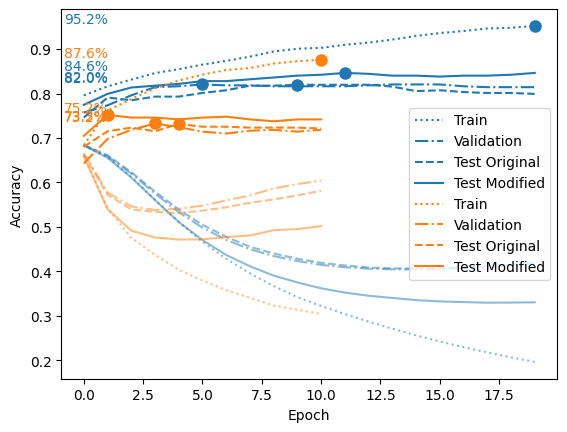

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Epoch', ylabel='Accuracy'>)

In [5]:
plot_results([
    "/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment/Projects/IMDB/model_outputs/integer_len64/MODEL_ENSEMBLE_6_BagOfWordsClassifierSimple__OPTIM_adam_opt__LR_0.001__BATCHSIZE_32__DATA_integer_len64_filtered__LOSS_cross_entropy.pkl",
    "/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment/Projects/IMDB/model_outputs/integer_len32/MODEL_ENSEMBLE_6_BagOfWordsClassifierSimple__OPTIM_adam_opt__LR_0.01__BATCHSIZE_32__DATA_integer_len32_filtered__LOSS_cross_entropy.pkl",
])

In [6]:

X_t = np.array([[0, 0, 0], [1, 1, 1]])
Y_t = np.array([[1, 0, 0], [1, 1, 0]])

dot = X_t @ Y_t.T

print(dot)

print(np.dot(X_t,Y_t.T))

X_norm = np.linalg.norm(X_t,ord=2)
Y_norm = np.linalg.norm(Y_t,ord=2)

print(X_t,Y_t,X_norm,Y_norm)
print(1-dot/(X_norm*Y_norm))


print("case 1")
A = np.array([[2, 1, 2, 3, 2, 9]])
B = np.array([[3, 4, 2, 4, 5, 5]]).T

# compute cosine similarity
cosine = 1 - np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))
print("Cosine Similarity:", cosine)

print("\n\ncase 2")
A = np.array([2, 1, 2, 3, 2, 9])
B = np.array([3, 4, 2, 4, 5, 5])

# compute cosine similarity
cosine = 1 - np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))
print("Cosine Similarity:", cosine)

print("\n\ncase 3")
A = np.array([[2, 1, 2, 3, 2, 9], [1, 1, 1, 1, 1, 1]])
B = np.array([[3, 4, 2, 4, 5, 5], [1, 1, 1, 1, 1, 1]]).T


# compute cosine similarity
cosine = 1 - np.dot(A, B) / (np.linalg.norm(A) * np.linalg.norm(B))
print("Cosine Similarity:", cosine)



[[0 0]
 [1 2]]
[[0 0]
 [1 2]]
[[0 0 0]
 [1 1 1]] [[1 0 0]
 [1 1 0]] 1.7320508075688772 1.618033988749895
[[1.         1.        ]
 [0.64317791 0.28635582]]
case 1
Cosine Similarity: [[0.18114953]]


case 2
Cosine Similarity: 0.18114952765147263


case 3
Cosine Similarity: [[0.22801105 0.81891617]
 [0.78079326 0.94281563]]
